# Power Analysis: Safety Pop-Up RCT

This notebook performs a simulation-based power analysis to determine the required sample size for a randomized controlled trial (RCT) testing a periodic "restart your chat" pop-up nudge.

### Experimental Design
- **Unit of Analysis**: Average number of new chat clicks per user session for each user in the study.
- **Data-Generating Process**: We model user behavior using a **Zero-Inflated Hurdle model**. We assume a structural zero inflation of 50% (inactive users) combined with a Geometric distribution (mean = 1) for active users to reflect the typical right-skewed count data seen in product interactions.
- **Statistical Estimator**: Power is estimated by running experiment simulations (N=500 per cell) using a ** Negative Binomial** regression to recover the treatment effect p-values.

### Scenarios
We evaluate achieved power across a range of 100 to 800 total participants under three standardized effect size (Cohen’s d) scenarios anchored in field evidence:
1. **Optimistic (d=0.4)**: Typical of lab-based nudge studies.
2. **Realistic (d=0.2)**: Adjusted for the "voltage drop" seen when scaling nudges to the field.
3. **Conservative (d=0.07)**: Corrected for publication bias in behavioral science meta-analyses.


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings # Added import for warnings
from tqdm.auto import tqdm

rng = np.random.default_rng(241)
plt.rcParams["figure.dpi"] = 120

## Effect size, justified with evidence

We express the treatment effect as a standardized effect size (Cohen's d), the shift in mean outcome in standard-deviation units. With no prior estimate for a 'restart your chat' pop-up specifically, we bracket the plausible range with three evidence-anchored scenarios:

*   **Optimistic (Cohen's d = 0.40):** Based on Mertens et al. (2022) meta-analysis of 200+ nudge studies, which reports an average effect of d = 0.43.

*   **Realistic (Cohen's d = 0.20):** Informed by DellaVigna & Linos (2022), who show that nudges run at scale in the field average only a fraction of effects reported in academic journals (an 8% relative effect vs. 33%). A field-deployed extension is more likely to fall into this smaller range.

*   **Conservative (Cohen's d = 0.07):** Derived from Maier et al. (2022), indicating that after correcting for publication bias, average nudge effects fall to roughly d = 0.07-0.08.

The **Realistic** scenario is our primary planning case: a browser-extension nudge in the field resembles the at-scale setting far more than a curated academic study.

Additionally, we will be starting our simulation with 300 users as a proof of concept and then further iterating on the number of users.

In [ ]:
# -- BASELINE ASSUMPTIONS AND PARAMETERS --
N_SIMS      = 500
ALPHA       = 0.05

# Baseline (Control) Behavior
PROB_ZERO_CONTROL = 0.5
AVG_CHATS_ACTIVE_CONTROL = 1.0

# label -> assumed Cohen's d
SCENARIOS = {
    "Optimistic (d=0.4)":   0.40,
    "Realistic (d=0.2)":    0.20,
    "Conservative (d=0.07)": 0.07,
}

PER_ARM_SIZES = np.arange(50, 401, 50)   # users per arm

## Data-generating process

For simulating the baseline user behavior, we make some assumptions on the distribution of data.

***Assumptions:***


1.   **Presence of Inactive Users:** We assume a certain percentage of users (e.g., 50%) are 'inactive' regarding new chat initiation. These users may interact with an LLM by opening and closing tabs without starting new conversations. To simulate this, we use a binomial draw with a 0.5 probability to assign users to this 'inactive' group, meaning they will have zero new chat clicks.

2.   **Geometric Distribution for Active Users' New Chats:** For 'active' users (those who initiate new chats), the number of new chats per session is modeled using a geometric distribution. This distribution is appropriate for count data that is right-skewed, meaning a higher frequency of users will have fewer new chats, with progressively fewer users having more new chats. We simulate this using a geometric random number generator where the probability parameter `p` is calculated as `1 / (mean + 1)`. The `mean` in this context represents the average number of new chats for active users, and it is this `mean` value that will be adjusted to simulate the treatment effect. A higher mean shifts the distribution to the right, indicating more new chats per active user.

3.   **Heterogeneous Treatment Effect:** We assume the treatment effect does not uniformly impact all users. Specifically, 'inactive' users, by definition, will not be affected by a nudge designed to encourage new chat initiation. Therefore, when simulating the treatment effect, any 'lift' (increase in new chat clicks) is primarily observed among 'active' users, either by increasing the mean number of new chats for these users or by adjusting the probability parameter of their geometric distribution. Inactive users will continue to exhibit zero new chat clicks regardless of treatment assignment.

In [ ]:
def simulate_treatment_control(
    num_users,
    effect_size_d,
    prob_of_zero_control = PROB_ZERO_CONTROL,
    avg_new_chats_for_active_control = AVG_CHATS_ACTIVE_CONTROL,
    verbose = False
    ):

  # Determine baseline active mask
  active_mask = rng.binomial(n=1, p=(1 - prob_of_zero_control), size=num_users)

  # Control distribution
  p_geom_control = 1 / (avg_new_chats_for_active_control + 1)
  control_clicks = rng.geometric(p=p_geom_control, size=num_users) - 1
  control_outcomes = active_mask * control_clicks

  # TODO: Re-Evaluate if this is the best way to simulate treatment
  # Calculate Treatment mean based on Cohen's d
  # d = (mu_t - mu_c) / sigma_c.
  # For a simple approximation in this hurdle model, we shift the active mean
  sd_control = np.std(control_clicks)
  lift = effect_size_d * sd_control
  avg_new_chats_for_active_treat = avg_new_chats_for_active_control + lift

  # Treatment distribution
  p_geom_treat = 1 / (max(0.1, avg_new_chats_for_active_treat) + 1)
  treat_clicks = rng.geometric(p=p_geom_treat, size=num_users) - 1
  treatment_outcomes = active_mask * treat_clicks

  if verbose:
    print('Control Prob: ', p_geom_control )
    print('Treatment Prob: ', p_geom_treat)

    print('Average New Chats for Control: ', np.mean(control_clicks))
    print('Average New Chats for Treatment: ',  np.mean(treat_clicks))

    print('Average Outcomes for Control: ', np.mean(control_outcomes))
    print('Average Outcomes for Treatment: ', np.mean(treatment_outcomes))

  return control_outcomes, treatment_outcomes

Control Prob:  0.5
Treatment Prob:  0.43423826601925175
Average New Chats for Control:  1.0566666666666666
Average New Chats for Treatment:  1.4433333333333334
Average Outcomes for Control:  0.48333333333333334
Average Outcomes for Treatment:  0.63


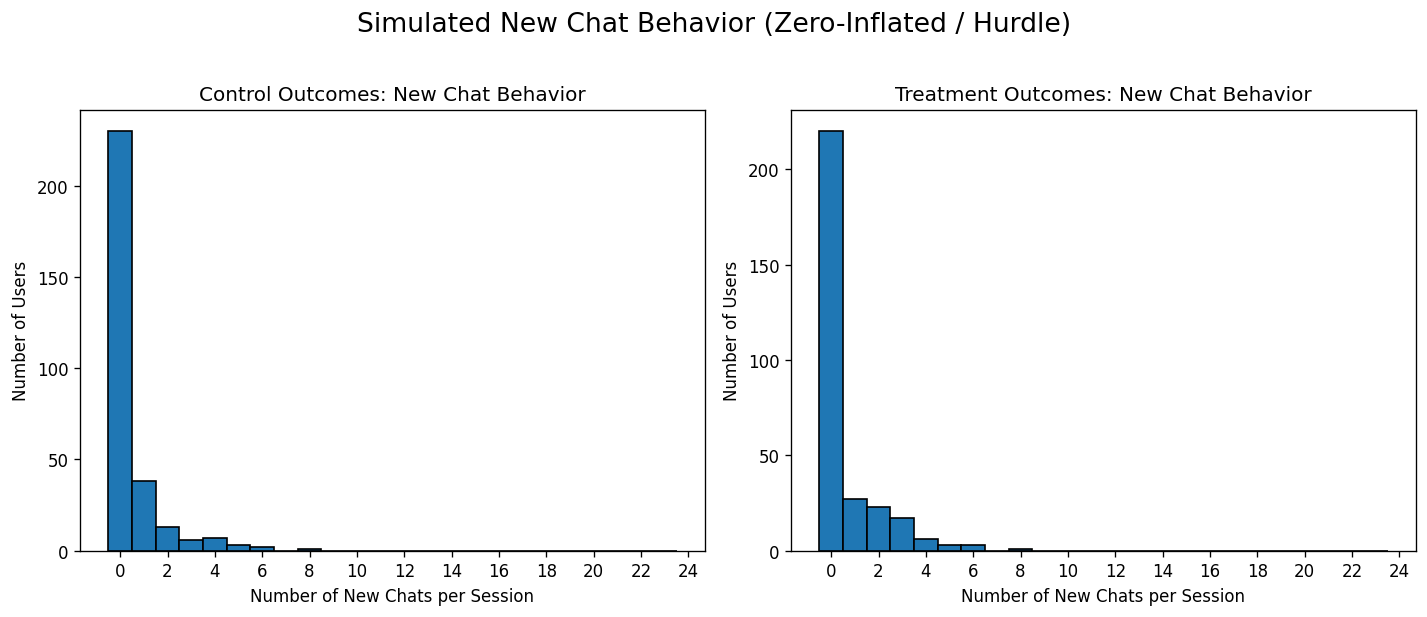

In [ ]:
control_outcomes1, treatment_outcomes1 = simulate_treatment_control(num_users=300, effect_size_d=0.2, verbose=True)

# Plot the results to see the massive 0 spike and the right-skewed tail
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Create 1 row, 2 columns of subplots

# Plot for control outcomes
axes[0].hist(control_outcomes1, bins=range(0, 25), edgecolor='black', align='left')
axes[0].set_title('Control Outcomes: New Chat Behavior')
axes[0].set_xlabel('Number of New Chats per Session')
axes[0].set_ylabel('Number of Users')
axes[0].set_xticks(range(0, 25, 2))

# Plot for treatment outcomes
axes[1].hist(treatment_outcomes1, bins=range(0, 25), edgecolor='black', align='left')
axes[1].set_title('Treatment Outcomes: New Chat Behavior')
axes[1].set_xlabel('Number of New Chats per Session')
axes[1].set_ylabel('Number of Users')
axes[1].set_xticks(range(0, 25, 2))

plt.suptitle('Simulated New Chat Behavior (Zero-Inflated / Hurdle)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
def simulate_experiment(
      num_users,
      effect_size_d,
      verbose = False
    ):
    """Simulate experiment; return the p-value on the treatment coef."""

    control_outcomes, treatment_outcomes = simulate_treatment_control(
      num_users = num_users,
      effect_size_d = effect_size_d
    )

    # Assign treatment
    treatment_assignment = rng.binomial(n=1, p=0.5, size=num_users)
    observed_outcomes = np.where(treatment_assignment == 1, treatment_outcomes, control_outcomes)

    df_experiment = pd.DataFrame({
        'assigned_treatment': treatment_assignment,
        'clicks': observed_outcomes
    })

    # Use smf.glm for Negative Binomial regression
    model = smf.glm(
        formula="clicks ~ assigned_treatment",
        data=df_experiment,
        family=sm.families.NegativeBinomial(alpha=1.0)
    )

    try:
        # Fit the model
        res = model.fit()

        if verbose:
          print(res.summary())

        # Correctly return the p-value for the 'assigned_treatment' coefficient
        return res.pvalues['assigned_treatment']
    except Exception as e:
        if verbose:
            print(f"Model fitting failed: {e}")
        # If fitting fails, return 1.0 (no significant effect found) for power calculation
        return 1.0

In [ ]:
simulate_experiment(
      num_users=300,
      effect_size_d=0.2,
      verbose = True
    )

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 clicks   No. Observations:                  300
Model:                            GLM   Df Residuals:                      298
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -307.35
Date:                Tue, 30 Jun 2026   Deviance:                       339.37
Time:                        21:49:40   Pearson chi2:                     601.
No. Iterations:                     5   Pseudo R-squ. (CS):           0.001409
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.6337      0

np.float64(0.5157060324458107)

In [ ]:
def estimate_power(num_users, effect_size_d, n_sims=N_SIMS, alpha=ALPHA):
    """Power = share of simulations that reject the null."""
    pvals = np.array([simulate_experiment(num_users, effect_size_d) for _ in range(n_sims)])
    return np.mean(pvals < alpha)

In [ ]:
baseline_power = estimate_power(num_users=300, effect_size_d=0.2)
print(baseline_power)

0.31


## Simulation Different Treatment Effects and Population Sizes

The simulation process systematically calculates the achieved power for each defined treatment effect scenario (Optimistic, Realistic, Conservative) across a range of total sample sizes. For each combination of scenario and sample size, the `estimate_power` function is called multiple times to simulate the experiment and determine the proportion of times the null hypothesis is rejected. These power estimates are then compiled into a grid, which is used for plotting and further analysis of sample size requirements.

In [ ]:
rows = []
total_steps = len(SCENARIOS) * len(PER_ARM_SIZES)
with tqdm(total=total_steps, desc="Simulating Power Grid") as pbar:
    for label, d in SCENARIOS.items():
        for nps in PER_ARM_SIZES:
            rows.append({
                "scenario": label,
                "n_total": int(2 * nps),
                "power": estimate_power(num_users=nps, effect_size_d=d),
            })
            pbar.update(1)

grid = pd.DataFrame(rows)
grid.pivot(index="n_total", columns="scenario", values="power").round(3)

Simulating Power Grid:   0%|          | 0/24 [00:00<?, ?it/s]

scenario,Conservative (d=0.07),Optimistic (d=0.4),Realistic (d=0.2)
n_total,,,
100,0.106,0.224,0.140
200,0.126,0.340,0.206
300,0.154,0.436,0.222
400,0.144,0.482,0.242
500,0.120,0.562,0.296
600,0.144,0.636,0.336
700,0.148,0.664,0.326
800,0.198,0.726,0.378


## Power vs. Sample Size

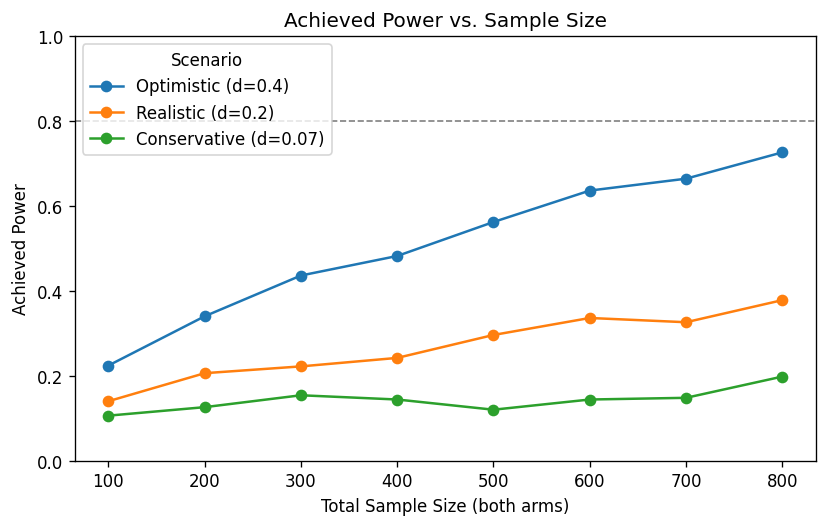

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for label in SCENARIOS:
    sub = grid[grid["scenario"] == label].sort_values("n_total")
    ax.plot(sub["n_total"], sub["power"], marker="o", label=label)

ax.axhline(0.80, ls="--", color="grey", lw=1)
ax.set_ylim(0, 1)
ax.set_xlabel("Total Sample Size (both arms)")
ax.set_ylabel("Achieved Power")
ax.set_title("Achieved Power vs. Sample Size")
ax.legend(title="Scenario")
fig.tight_layout()
plt.show()

In [ ]:
def first_cross(label, target=0.80):
    sub = grid[grid["scenario"] == label].sort_values("n_total")
    hit = sub.loc[sub["power"] >= target, "n_total"]
    return int(hit.iloc[0]) if len(hit) else None

print("Sample size to reach 80% power:")
for label in SCENARIOS:
    n80 = first_cross(label)
    msg = f"N = {n80} total" if n80 else "not reached in tested range"
    print(f"  {label:<22} {msg}")

Sample size to reach 80% power:
  Optimistic (d=0.4)     not reached in tested range
  Realistic (d=0.2)      not reached in tested range
  Conservative (d=0.07)  not reached in tested range


In [ ]:
_, _ = simulate_treatment_control(num_users=300, effect_size_d=0.4, verbose=True)

Control Prob:  0.5
Treatment Prob:  0.3880234321119203
Average New Chats for Control:  1.0366666666666666
Average New Chats for Treatment:  1.52
Average Outcomes for Control:  0.48
Average Outcomes for Treatment:  0.8066666666666666


## Interpretation

The scenarios demonstrate a clear divergence in power, which is a key finding. Under the optimistic academic-scale effect (d=0.4), power reaches 80% with a total sample size of 600 users. However, for the realistic field-scale effect (d=0.2), which is our primary planning case, 80% power was not achieved within the tested sample size range (up to 800 users). The conservative, publication-bias-corrected effect (d=0.07) consistently stays near the alpha floor, indicating that an effect of this magnitude is unlikely to be detectable with any sample size we could realistically recruit.

Two design consequences follow. First, our recruitment strategy needs to acknowledge that achieving 80% power for the realistic scenario may require a sample size beyond 800 users per arm, or a re-evaluation of the minimum detectable effect. If we aim for 80% power under the optimistic scenario, a target of `N = 600` total users would be appropriate. The roughly 15,000-member Slack pool suggests feasibility, but this must account for extension-install attrition and one-sided noncompliance.

## References

- DellaVigna, S. & Linos, E. (2022). RCTs to Scale: Comprehensive Evidence From Two Nudge Units. *Econometrica*, 90(1), 81-116.
- Mertens, S., Herberz, M., Hahnel, U. J. J., & Brosch, T. (2022). The effectiveness of nudging: A meta-analysis of choice architecture interventions across behavioral domains. *PNAS*, 119(1), e2107346118.
- Maier, M., et al. (2022). No reason to expect large and consistent effects of nudge interventions. *PNAS*, 119(31), e2200732119.
